In [ ]:
from collections import Counter
import pandas as pd
import numpy as np

file_path = r"C:\Users\14748\Desktop\machine learning\yelp_academic_dataset_business.json"

df = pd.read_json(file_path, lines=True)

print("Initial shape:", df.shape)
df.head()

category_counter = Counter()

for cats in df['categories'].dropna():
    for c in cats.split(','):
        category_counter[c.strip()] += 1

# 转 DataFrame 
cat_df = pd.DataFrame(category_counter.items(), columns=['category', 'count'])
cat_df = cat_df.sort_values(by='count', ascending=False)

attr_counter = Counter()

for attr in df['attributes']:
    if isinstance(attr, dict):
        for key in attr.keys():
            attr_counter[key] += 1

attr_df = pd.DataFrame(attr_counter.items(), columns=['attribute', 'count'])
attr_df = attr_df.sort_values(by='count', ascending=False)

price_counter = Counter()

print("Category counts (all):")
for cat, count in category_counter.most_common():
    print(f"{cat}: {count}")

print("Attribute counts (all):")
for attr, count in attr_counter.most_common():
    print(f"{attr}: {count}")

Initial shape: (150346, 14)
Attribute counts (all):
BusinessAcceptsCreditCards: 119765
BusinessParking: 91085
RestaurantsPriceRange2: 85314
BikeParking: 72638
RestaurantsTakeOut: 59857
WiFi: 56914
RestaurantsDelivery: 56282
GoodForKids: 53375
OutdoorSeating: 48802
RestaurantsReservations: 45247
HasTV: 45084
Ambience: 44279
RestaurantsGoodForGroups: 44170
Alcohol: 43189
ByAppointmentOnly: 42339
Caters: 40127
RestaurantsAttire: 39255
NoiseLevel: 37993
GoodForMeal: 29087
WheelchairAccessible: 28953
RestaurantsTableService: 19982
DogsAllowed: 18284
BusinessAcceptsBitcoin: 17430
HappyHour: 15171
DriveThru: 7760
Music: 7521
AcceptsInsurance: 5713
BestNights: 5694
CoatCheck: 5584
GoodForDancing: 4628
Smoking: 4567
BYOB: 4451
Corkage: 3553
BYOBCorkage: 1444
HairSpecializesIn: 1065
AgesAllowed: 129
Open24Hours: 39
DietaryRestrictions: 31
RestaurantsCounterService: 19


Initial shape: (150346, 14)
Cleaned shape: (8536, 4)


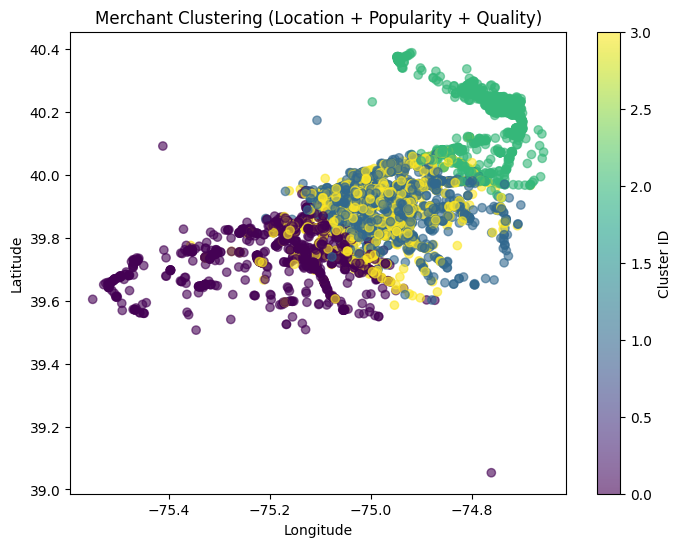

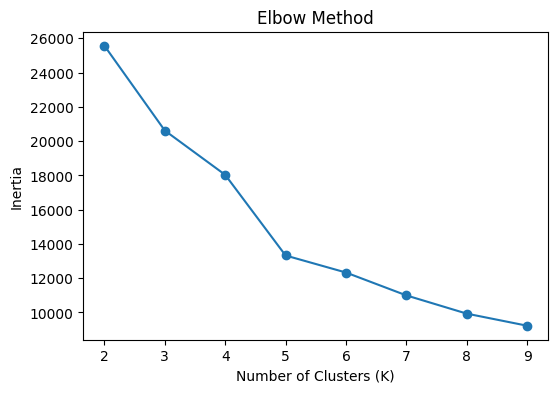

          latitude  longitude     stars  review_count
cluster                                              
0        39.754718 -75.151811  3.695099     20.887333
1        39.901386 -74.980172  4.105168     40.883953
2        40.176551 -74.788490  3.566641     28.814497
3        39.886726 -74.992744  2.343869     18.865992


In [4]:
# Merchant Clustering MVP (Enhanced Version)
# Goal: Demonstrate feasibility of commercial zoning using combined geographic + business features

# =====================
# 1. Import Libraries
# =====================
from matplotlib import colors
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# =====================
# 2. Load Data
# =====================
file_path = r"C:\Users\14748\Desktop\machine learning\yelp_academic_dataset_business.json"  

df = pd.read_json(file_path, lines=True)

print("Initial shape:", df.shape)

# =====================
# 3. Data Cleaning
# =====================


selected_state = "NJ"  
df = df[df['state'] == selected_state]

# Keep only rows with key features
features = ['latitude', 'longitude', 'stars', 'review_count']
df = df[features]

# Handle missing values

df = df.dropna()

print("Cleaned shape:", df.shape)

# =====================
# 4. Feature Scaling
# =====================
# IMPORTANT: prevents location from dominating clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# =====================
# 5. KMeans Clustering
# =====================
k = 4  # you can tune this using elbow method
kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# =====================
# 6. Visualization (Geographic)
# =====================
plt.figure(figsize=(8,6))
plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Merchant Clustering (Location + Popularity + Quality)")
plt.colorbar(label='Cluster ID')
plt.show()


import folium

# 先定义颜色列表，一定要是 list
colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred']

# 创建地图
m = folium.Map(
    location=[df['latitude'].mean(), df['longitude'].mean()],
    zoom_start=11
)

# 遍历数据加点
for _, row in df.iterrows():
    cluster_idx = int(row['cluster'])  # 确保是整数
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        color=colors[cluster_idx % len(colors)],
        fill=True,
        fill_color=colors[cluster_idx % len(colors)],
        fill_opacity=0.7,
        tooltip=f"Cluster {cluster_idx}"
    ).add_to(m)



m.save("merchant_clusters.html")  # 


# =====================
# 7. Elbow Method (Optional)
# =====================
inertia = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# =====================
# 8. Cluster Analysis
# =====================
cluster_summary = df.groupby('cluster').mean()
print(cluster_summary)

# =====================
# 9. Insights (WRITE IN MARKDOWN IN NOTEBOOK)
# =====================
# Example interpretation:
# Cluster 0:
#   - High stars + high review_count → popular and high-quality commercial areas
# Cluster 1:
#   - Low review_count → low traffic / residential businesses
# Cluster 2:
#   - Geographically concentrated → potential business hubs
# Cluster 3:
#   - Mixed → transitional or developing areas

